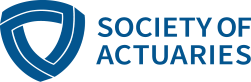


# 💀 03 Baseline Mortality Model

|                  |                                                                                             |
| ---------------- | ------------------------------------------------------------------------------------------- |
| Title            | 03 Baseline Mortality Model                                                                 |
| Case Study       | Climate-Adjusted Mortality for Selected EU Countries                                        |
| Research Project | CC230 Quantifying Mortality and Morbidity Impacts from Climate Risks                       |
| Notebook         | `03_baseline_mortality_model.ipynb`                                                         |
| Authors          | Carlos Arocha, FSA, SCR                                                                     |
| Sponsor          | Catastrophe and Climate Strategic Research Program, Society of Actuaries Research Institute |
| Date             | `2026-05-11`                                                                                |
| Version          | `v1.0.0`                                                                                    |
| Questions?       | Questions regarding this notebook should be directed to the SOA project contact             |

---

## Purpose

Estimate the non-climate mortality structure before introducing $C_{t,r}$, using the reduced form of the Climate-Adjusted Lee-Carter Mortality Model (cf. `Quantifying Mortality and Morbidity Impacts for Climate Risks` report):

$\log{m_{x, t, r}}=a_{x, r} + b_xk_t+\lambda_{x, r}C_{t, r}+\epsilon_{x, t, r}$

In this notebook, we will focus only on $a_{x, r}$, $b_x$. and $k_t$ and leave $\lambda_{x, r}$ and $C_{t,r}$ for the next notebook (i.e., `04_climate_calibration.ipynb`.)

---

## Inputs

NOTE: Inputs depend on the scenario selected in Notebook `01_data_ingestion_and_preparation.ipynb`
- `CC230 Toolkit/data/processed/mortality/mortality_country_age_year_2004_2025_excl_2020_2021_age20_85.csv`
- `CC230 Toolkit/config/model_config.yaml`

---

## Outputs
- `CC230 Toolkit/outputs/baseline_parameters_a_xr.csv`
- `CC230 Toolkit/outputs/baseline_parameters_b_x.csv`
- `CC230 Toolkit/outputs/baseline_parameters_k_t.csv`
- `CC230 Toolkit/outputs/baseline_fitted_mortality_2004_2021_excl_2020_2021_age20_85.csv`
- `CC230 Toolkit/outputs/baseline_residuals_2004_2021_excl_2020_2021_age20_85.csv`

Report:
- `CC230 Toolkit/reports/{NOTEBOOK}.html`

---

## Dependencies

This notebook can be run in Google Colab or any compatible Jupyter environment, such as:

* JupyterLab
* Jupyter Notebook
* VS Code with the Jupyter extension
* Anaconda Navigator
* Kaggle Notebooks

The notebook was developed using:

* Python 3.14.5
* Required libraries installed through the setup cell below

---

## Disclaimer
The Jupyter notebooks available through this repository are provided for research, educational, and illustrative purposes only. They are not intended to constitute actuarial advice or to represent production-ready systems without further validation, customization, and governance by the user.

While reasonable efforts have been made to ensure accuracy and consistency, no guarantee is given as to completeness, fitness for a particular purpose, or compliance with applicable actuarial standards or regulatory requirements.

Users are responsible for assessing the suitability of the materials for their specific use cases and for implementing appropriate controls, validation, and documentation prior to any operational use.

---

## License
© 2026 Society of Actuaries. Except where otherwise noted, the textual content of this book is licensed under the Creative Commons Attribution–Noncommercial–Share Alike 4.0 International License (CC BY-NC-SA 4.0). Source code samples, including scripts, notebooks, and code blocks where indicated, are licensed under the MIT License, unless otherwise stated.

---

## Setup and Shared Configuration

In [1]:
# Setup and shared configuration

from pathlib import Path, PureWindowsPath
import json
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if PROJECT_ROOT.parts[-1] != "CC230 Toolkit":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()

INTERIM_DATA_PATH = PROJECT_ROOT / "data" / "interim"
run_config_file = INTERIM_DATA_PATH / "run_config.json"
input_manifest_file = INTERIM_DATA_PATH / "input_manifest.csv"
notebook1_output_manifest_file = INTERIM_DATA_PATH / "01_data_ingestion_and_preparation_output_manifest.csv"
notebook2_output_manifest_file = INTERIM_DATA_PATH / "02_climate_features_output_manifest.csv"

NOTEBOOK_FILE = PROJECT_ROOT / "notebooks" / "03_baseline_mortality_model.ipynb"    

required_control_files = {
    "run_config": run_config_file,
    "input_manifest": input_manifest_file,
    "notebook1_output_manifest": notebook1_output_manifest_file,
}

for label, file_path in required_control_files.items():
    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing {label}: {file_path}. "
            "Run Notebook 1 first: 01_data_ingestion_and_preparation.ipynb"
        )

with open(run_config_file, "r", encoding="utf-8") as f:
    RUN_CONFIG = json.load(f)

input_manifest = pd.read_csv(input_manifest_file)
notebook1_output_manifest = pd.read_csv(notebook1_output_manifest_file)

notebook2_output_manifest = (
    pd.read_csv(notebook2_output_manifest_file)
    if notebook2_output_manifest_file.exists()
    else pd.DataFrame()
)

print("Loaded control files:")
print(" -", PureWindowsPath(run_config_file).name)
print(" -", PureWindowsPath(input_manifest_file).name)
print(" -", PureWindowsPath(notebook1_output_manifest_file).name)

if notebook2_output_manifest_file.exists():
    print(" -", PureWindowsPath(notebook2_output_manifest_file).name)
else:
    print(
        "Warning: Notebook 2 output manifest was not found. "
        "This notebook can estimate baseline mortality without Notebook 2 outputs, "
        "but the full pipeline should normally run Notebook 2 before Notebook 3."
    )

pd.set_option("display.max_columns", None)

Loaded control files:
 - run_config.json
 - input_manifest.csv
 - 01_data_ingestion_and_preparation_output_manifest.csv
 - 02_climate_features_output_manifest.csv


## Settings Imported from Notebook 01

In [2]:
# Settings from Notebook 01

DATA_PATH = Path(RUN_CONFIG["data_path"])
RAW_DATA_PATH = Path(RUN_CONFIG["raw_data_path"])
PROCESSED_DATA_PATH = Path(RUN_CONFIG["processed_data_path"])
OUTPUT_PATH = Path(RUN_CONFIG["output_path"])

REPORTS_PATH = PROJECT_ROOT / "reports"

SCENARIO = RUN_CONFIG["scenario"]
COUNTRIES = RUN_CONFIG["countries"]

CALIBRATION_START_YEAR = int(RUN_CONFIG["calibration_start_year"])
CALIBRATION_END_YEAR = int(RUN_CONFIG["calibration_end_year"])
EXCLUDED_CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["excluded_calibration_years"]]
CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["calibration_years"]]
CALIBRATION_YEARS_LABEL = RUN_CONFIG["calibration_years_label"]
N_CALIBRATION_YEARS = int(RUN_CONFIG["n_calibration_years"])

AGE_MIN = int(RUN_CONFIG["age_min"])
AGE_MAX = int(RUN_CONFIG["age_max"])
AGE_RANGE_LABEL = RUN_CONFIG["age_range_label"]

files = RUN_CONFIG.get("files", {})
mortality_file = Path(files["mortality_output_file"])

# Mortality-rate bounds used only for data cleaning.
MIN_MX = 1e-10
MAX_MX = 1.0

# Notebook 3 output files
a_out = OUTPUT_PATH / f"baseline_parameters_a_xr_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
b_out = OUTPUT_PATH / f"baseline_parameters_b_x_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
k_out = OUTPUT_PATH / f"baseline_parameters_k_t_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
fit_out = OUTPUT_PATH / f"baseline_fitted_mortality_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
resid_out = OUTPUT_PATH / f"baseline_residuals_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
diag_out = OUTPUT_PATH / f"baseline_residual_diagnostics_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"

notebook3_output_manifest_file = INTERIM_DATA_PATH / "03_baseline_mortality_model_output_manifest.csv"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "notebook": "03_baseline_mortality_model.ipynb",
    "run_timestamp_utc": datetime.now(UTC).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "scenario": SCENARIO,
    "countries": COUNTRIES,
    "calibration_years": CALIBRATION_YEARS,
    "age_min": AGE_MIN,
    "age_max": AGE_MAX,
}

print(json.dumps(RUN_METADATA, indent=2))
print("Mortality input file:", PureWindowsPath(mortality_file).name)

{
  "notebook": "03_baseline_mortality_model.ipynb",
  "run_timestamp_utc": "2026-06-19T14:11:58.563907+00:00",
  "project_root": "C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit",
  "scenario": "ssp5_8_5",
  "countries": [
    "ES",
    "FR",
    "IT"
  ],
  "calibration_years": [
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2022,
    2023,
    2024,
    2025
  ],
  "age_min": 20,
  "age_max": 85
}
Mortality input file: country_age_year_2004_2025_excl_2020_2021_age20_85.csv


## Helper Functions

In [3]:
# Helper functions

def ensure_columns(df, required_cols, label):
    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing required columns: {sorted(missing)}")

def path_to_project_relative(path):
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def register_file(role, path, file_type="csv", required=True, stage="output", notes=None):
    path = Path(path)
    return {
        "stage": stage,
        "role": role,
        "file_name": path.name,
        "relative_path": path_to_project_relative(path),
        "absolute_path": str(path),
        "file_type": file_type,
        "required": bool(required),
        "exists": path.exists(),
        "notes": notes,
    }

def require_file(path, label):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found for {label}: {path}. "
            "Run the preceding notebooks and review the manifest files."
        )
    return path

require_file(mortality_file, "processed mortality input")

print("Required Notebook 3 input file was found.")

Required Notebook 3 input file was found.


## Load and Validate Mortality Dataset

The baseline mortality model uses the processed mortality file created by Notebook 01. The expected columns are `country`, `year`, `age`, and `mx`.

In [4]:
# Load and validate mortality dataset

mortality = pd.read_csv(mortality_file)

# Standardize column names
mortality.columns = (
    mortality.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

ensure_columns(
    mortality,
    ["country", "year", "age", "mx"],
    "Processed mortality dataset",
)

mortality["year"] = pd.to_numeric(mortality["year"], errors="coerce").astype("Int64")
mortality["mx"] = pd.to_numeric(mortality["mx"], errors="coerce")

# Create numeric age for sorting and filtering
mortality["age_num"] = (
    mortality["age"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

mortality = mortality.dropna(subset=["year", "age_num", "mx"]).copy()
mortality["year"] = mortality["year"].astype(int)

# Filter using Notebook 1 parameters
mortality = mortality[
    mortality["country"].isin(COUNTRIES)
    & mortality["year"].isin(CALIBRATION_YEARS)
    & mortality["age_num"].between(AGE_MIN, AGE_MAX)
].copy()

# Clean mortality rates
mortality = mortality[
    mortality["mx"].notna()
    & (mortality["mx"] > MIN_MX)
    & (mortality["mx"] < MAX_MX)
].copy()

mortality["log_mx"] = np.log(mortality["mx"])

coverage = (
    mortality
    .groupby("country", as_index=False)
    .agg(
        n_years=("year", "nunique"),
        min_year=("year", "min"),
        max_year=("year", "max"),
        n_ages=("age_num", "nunique"),
        min_age=("age_num", "min"),
        max_age=("age_num", "max"),
        n_rows=("mx", "size"),
    )
)

print("Countries:", sorted(mortality["country"].unique()))
print("Calibration years:", min(CALIBRATION_YEARS), "to", max(CALIBRATION_YEARS))
print("Excluded calibration years:", EXCLUDED_CALIBRATION_YEARS)
print("Age range:", mortality["age_num"].min(), "to", mortality["age_num"].max())
print("Rows after preparation:", len(mortality))

missing_country_years = (
    pd.MultiIndex.from_product(
        [COUNTRIES, CALIBRATION_YEARS],
        names=["country", "year"],
    )
    .to_frame(index=False)
    .merge(
        mortality[["country", "year"]].drop_duplicates(),
        on=["country", "year"],
        how="left",
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

if not missing_country_years.empty:
    print("Warning: missing country-year combinations:")
    display(missing_country_years)
else:
    print("All expected country-year combinations are present.")

Countries: ['ES', 'FR', 'IT']
Calibration years: 2004 to 2025
Excluded calibration years: [2020, 2021]
Age range: 20.0 to 85.0
Rows after preparation: 3960
All expected country-year combinations are present.


## Estimate $a_{x, r}$

In [5]:
# Estimate a_{x,r}

a_cols = ["age", "age_num", "country"]

a_xr = (
    mortality
    .groupby(a_cols, as_index=False)
    .agg(
        a_xr_initial=("log_mx", "mean"),
        n_years=("year", "nunique"),
    )
)

mortality = mortality.merge(
    a_xr[["age", "age_num", "country", "a_xr_initial"]],
    on=a_cols,
    how="left",
    validate="many_to_one",
)

mortality["y_centered_initial"] = (
    mortality["log_mx"] - mortality["a_xr_initial"]
)

## Estimate $b_x$ and $k_t$

The centered mortality matrix is constructed by averaging centered log mortality across countries for each age-year cell. Singular value decomposition (SVD) is then used to estimate the first Lee-Carter age sensitivity vector $b_x$ and time index $k_t$.

In [6]:
# Build the age-year matrix for the SVD

lc_excluded_years = set(EXCLUDED_CALIBRATION_YEARS)

mortality_lc = mortality[
    ~mortality["year"].isin(lc_excluded_years)
].copy()

if mortality_lc.empty:
    raise ValueError(
        "No mortality observations remain after applying the Lee-Carter "
        "excluded-year filter."
    )

age_year_centered = (
    mortality_lc
    .groupby(["age", "age_num", "year"], as_index=False)
    .agg(
        y_centered_mean=("y_centered_initial", "mean"),
        n_countries=("country", "nunique"),
    )
)

# Build the age-year matrix used in the SVD:
# rows    = ages
# columns = years
# values  = centered log mortality
lc_matrix = (
    age_year_centered
    .pivot(
        index="age",
        columns="year",
        values="y_centered_mean",
    )
)

age_order = (
    age_year_centered[["age", "age_num"]]
    .drop_duplicates()
    .sort_values("age_num")
)

lc_matrix = lc_matrix.loc[age_order["age"]]

lc_matrix = lc_matrix.reindex(sorted(lc_matrix.columns), axis=1)

lc_matrix = lc_matrix.astype(float)

svd_years = [int(y) for y in lc_matrix.columns]

expected_lc_years = [
    int(y)
    for y in CALIBRATION_YEARS
    if int(y) not in lc_excluded_years
]

missing_svd_years = sorted(set(expected_lc_years) - set(svd_years))
extra_svd_years = sorted(set(svd_years) - set(expected_lc_years))

print("LC calibration years requested:", CALIBRATION_YEARS)
print("LC excluded years:", sorted(lc_excluded_years))
print("LC years expected in SVD:", expected_lc_years)
print("LC years actually used in SVD:", svd_years)

if missing_svd_years:
    raise ValueError(
        "Unexpected missing years in the Lee-Carter SVD matrix: "
        f"{missing_svd_years}. "
        "These years are not listed as excluded calibration years."
    )

if extra_svd_years:
    raise ValueError(
        "Unexpected extra years in the Lee-Carter SVD matrix: "
        f"{extra_svd_years}. "
        "Check the calibration-year filtering."
    )

if lc_matrix.isna().any().any():
    missing_cells = int(lc_matrix.isna().sum().sum())

    missing_by_year = (
        lc_matrix
        .isna()
        .sum(axis=0)
        .astype(int)
    )

    missing_by_year = missing_by_year[missing_by_year > 0]

    display(
        missing_by_year
        .rename("missing_age_cells")
        .reset_index()
        .rename(columns={"year": "year"})
    )

    raise ValueError(
        f"The Lee-Carter matrix contains {missing_cells} missing age-year cells. "
        "This is different from excluding full years such as 2020 and 2021. "
        "Check mortality coverage before estimating the model."
    )

if lc_matrix.shape[0] < 2:
    raise ValueError(
        "The Lee-Carter matrix has fewer than two ages. "
        "SVD estimation is not meaningful."
    )

if lc_matrix.shape[1] < 2:
    raise ValueError(
        "The Lee-Carter matrix has fewer than two years. "
        "SVD estimation of k_t is not meaningful."
    )

print("LC matrix shape:", lc_matrix.shape)
print("Number of ages:", lc_matrix.shape[0])
print("Number of SVD years:", lc_matrix.shape[1])

LC calibration years requested: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
LC excluded years: [2020, 2021]
LC years expected in SVD: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
LC years actually used in SVD: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
LC matrix shape: (66, 20)
Number of ages: 66
Number of SVD years: 20


In [7]:
# Estimate b_x and k_t using SVD

Y = lc_matrix.values

U, S, Vt = np.linalg.svd(Y, full_matrices=False)

ages = lc_matrix.index
years = lc_matrix.columns.astype(int)

b_raw = pd.Series(U[:, 0], index=ages, name="b_x")
k_raw = pd.Series(S[0] * Vt[0, :], index=years, name="k_t")

scale = b_raw.sum()

if np.isclose(scale, 0):
    raise ValueError("The estimated Lee-Carter b_x vector has near-zero sum and cannot be normalized.")

b_x = b_raw / scale
k_t = k_raw * scale

# Orient k_t so that the time index is decreasing when mortality improves.
if k_t.iloc[-1] > k_t.iloc[0]:
    b_x = -b_x
    k_t = -k_t

k_mean = k_t.mean()
k_t_centered = k_t - k_mean

b_x_df = (
    b_x
    .reset_index()
    .rename(columns={"index": "age", "b_x": "b_x"})
)

b_x_df["b_x"] = b_x_df["b_x"].astype(float)

k_t_df = (
    k_t_centered
    .reset_index()
    .rename(columns={"index": "year", "k_t": "k_t"})
)

k_t_df["year"] = k_t_df["year"].astype(int)

print("Sum of b_x:", "%.3f"%b_x_df["b_x"].sum())
print("Mean of centered k_t:", "%.3f"%k_t_df["k_t"].mean())

Sum of b_x: 1.000
Mean of centered k_t: -0.000


b_x diagnostics


count    66.000000
mean      0.015152
std       0.005228
min       0.007222
1%        0.007366
5%        0.007923
25%       0.010479
50%       0.013556
75%       0.019868
95%       0.023465
99%       0.025313
max       0.027065
Name: b_x, dtype: float64

Sum of b_x: 1.0
Min b_x: 0.007222264733534511
Max b_x: 0.027065368019014283
Number of negative b_x values: 0
Number of ages: 66


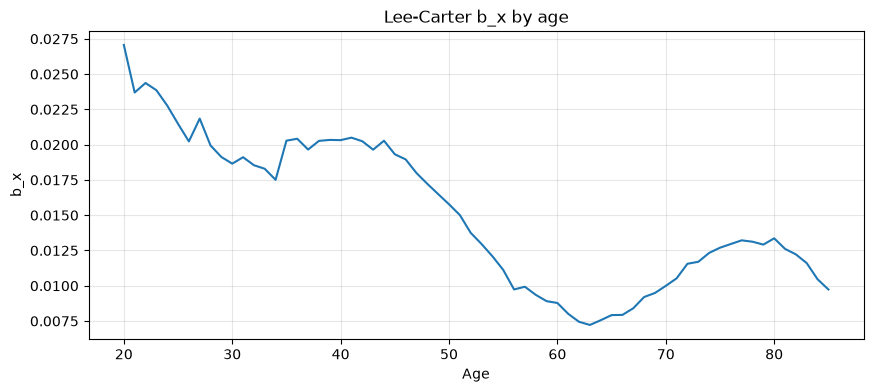

In [8]:
# Diagnostic 1: scale and shape of b_x

bx_diag = b_x.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

print("b_x diagnostics")
display(bx_diag)

print("Sum of b_x:", b_x.sum())
print("Min b_x:", b_x.min())
print("Max b_x:", b_x.max())
print("Number of negative b_x values:", int((b_x < 0).sum()))
print("Number of ages:", len(b_x))

b_x.plot(
    title="Lee-Carter b_x by age",
    xlabel="Age",
    ylabel="b_x",
    figsize=(10, 4),
)
plt.grid(True, alpha=0.3)
plt.show()

Range of b_x * k_t:
Minimum: -0.44773673504809497
Maximum: 0.43379951489038865


count    1.320000e+03
mean    -6.476301e-18
std      1.451142e-01
min     -4.477367e-01
1%      -3.375000e-01
5%      -2.257834e-01
25%     -8.291371e-02
50%     -3.230941e-02
75%      9.617033e-02
95%      2.574797e-01
99%      3.269943e-01
max      4.337995e-01
Name: b_x_k_t, dtype: float64

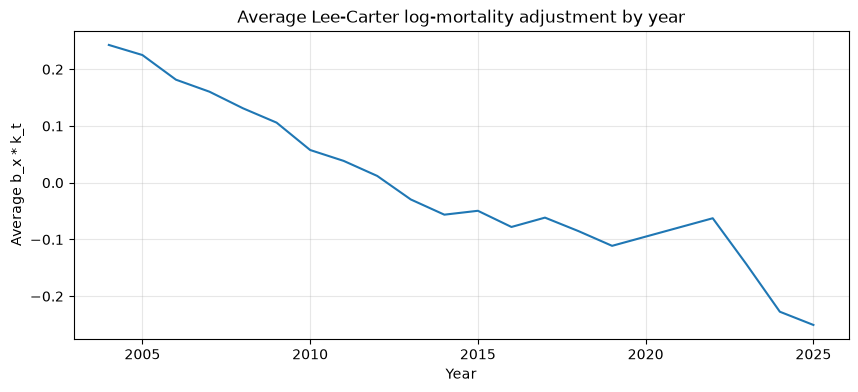

In [9]:
# Diagnostic 2: actual fitted Lee-Carter adjustment range

lc_effect = pd.DataFrame(
    np.outer(b_x.values, k_t_centered.values), # type: ignore
    index=b_x.index,
    columns=k_t_centered.index,
)

print("Range of b_x * k_t:")
print("Minimum:", lc_effect.min().min())
print("Maximum:", lc_effect.max().max())

display(
    lc_effect.stack()
    .rename("b_x_k_t") # type: ignore
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

plt.figure(figsize=(10, 4))
lc_effect.mean(axis=0).plot()
plt.title("Average Lee-Carter log-mortality adjustment by year")
plt.xlabel("Year")
plt.ylabel("Average b_x * k_t")
plt.grid(True, alpha=0.3)
plt.show()

,singular_value,variance_share,cumulative_share
0,5.270264,0.967410,0.967410
1,0.665487,0.015425,0.982835
2,0.313213,0.003417,0.986252
3,0.286672,0.002862,0.989115
4,0.250693,0.002189,0.991304
5,0.220590,0.001695,0.992998
6,0.194303,0.001315,0.994313
7,0.170464,0.001012,0.995325
8,0.162495,0.000920,0.996245
9,0.151458,0.000799,0.997044


First component variance share: 0.9674104596583006


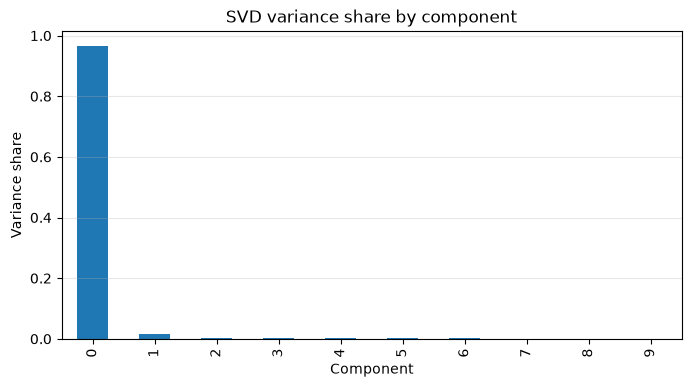

In [10]:
# Diagnostic 3: variance explained by SVD components

singular_values = pd.Series(S, name="singular_value")
variance_share = pd.Series(S**2 / np.sum(S**2), name="variance_share")
cumulative_share = variance_share.cumsum().rename("cumulative_share")

svd_diag = pd.concat(
    [singular_values, variance_share, cumulative_share],
    axis=1,
)

display(svd_diag.head(10))

print("First component variance share:", variance_share.iloc[0])

variance_share.head(10).plot(
    kind="bar",
    title="SVD variance share by component",
    xlabel="Component",
    ylabel="Variance share",
    figsize=(8, 4),
)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Fitted Values and Residuals

The final $a_{x,r}$ parameter is adjusted to reflect the centering of $k_t$. The fitted baseline log mortality rate is then calculated as $\log \hat{m}^{\,base}_{x,t,r} = a_{x,r} + b_x k_t$.

In [11]:
# Fitted values and residuals

a_xr_final = a_xr.merge(
    b_x_df,
    on="age",
    how="inner",
    validate="many_to_one",
)

a_xr_final["a_xr"] = (
    a_xr_final["a_xr_initial"]
    + a_xr_final["b_x"] * k_mean
)

a_xr_final = a_xr_final[
    ["age", "age_num", "country", "a_xr"]
].copy()

baseline_fit = mortality.merge(
    a_xr_final,
    on=["age", "age_num", "country"],
    how="inner",
    validate="many_to_one",
)

baseline_fit = baseline_fit.merge(
    b_x_df,
    on="age",
    how="inner",
    validate="many_to_one",
)

baseline_fit = baseline_fit.merge(
    k_t_df,
    on="year",
    how="inner",
    validate="many_to_one",
)

baseline_fit["log_mx_hat_baseline"] = (
    baseline_fit["a_xr"]
    + baseline_fit["b_x"] * baseline_fit["k_t"]
)

baseline_fit["mx_hat_baseline"] = np.exp(
    baseline_fit["log_mx_hat_baseline"]
)

baseline_fit["baseline_residual"] = (
    baseline_fit["log_mx"]
    - baseline_fit["log_mx_hat_baseline"]
)

## Save Outputs and Write Notebook 03 Manifest

The outputs form this notebook are used by Notebook 04 to calibrate the climate-related mortality component.

In [12]:
# Save outputs

a_xr_final.to_csv(a_out, index=False)
b_x_df.to_csv(b_out, index=False)
k_t_df.to_csv(k_out, index=False)
baseline_fit.to_csv(fit_out, index=False)

baseline_residuals = baseline_fit[
    [
        "country",
        "year",
        "age",
        "age_num",
        "mx",
        "log_mx",
        "mx_hat_baseline",
        "log_mx_hat_baseline",
        "baseline_residual",
    ]
].copy()

baseline_residuals.to_csv(resid_out, index=False)

print("Saved baseline model outputs:")
for file_path in [a_out, b_out, k_out, fit_out, resid_out, diag_out]:
    print(f"  - {PureWindowsPath(file_path).name}")

Saved baseline model outputs:
  - baseline_parameters_a_xr_2004_2025_excl_2020_2021_age20_85.csv
  - baseline_parameters_b_x_2004_2025_excl_2020_2021_age20_85.csv
  - baseline_parameters_k_t_2004_2025_excl_2020_2021_age20_85.csv
  - baseline_fitted_mortality_2004_2025_excl_2020_2021_age20_85.csv
  - baseline_residuals_2004_2025_excl_2020_2021_age20_85.csv
  - baseline_residual_diagnostics_2004_2025_excl_2020_2021_age20_85.csv


In [13]:
output_records = [
    register_file(
        role="baseline_parameter_a_xr",
        path=a_out,
        notes="Estimated baseline mortality level by age and country",
    ),
    register_file(
        role="baseline_parameter_b_x",
        path=b_out,
        notes="Estimated Lee-Carter age sensitivity vector",
    ),
    register_file(
        role="baseline_parameter_k_t",
        path=k_out,
        notes="Estimated centered Lee-Carter time index",
    ),
    register_file(
        role="baseline_fitted_mortality",
        path=fit_out,
        notes="Observed and fitted baseline mortality rates",
    ),
    register_file(
        role="baseline_residuals",
        path=resid_out,
        notes="Age-country-year baseline residuals",
    ),    
]

notebook3_output_manifest = pd.DataFrame(output_records)
notebook3_output_manifest.to_csv(notebook3_output_manifest_file, index=False)

missing_outputs = notebook3_output_manifest[
    notebook3_output_manifest["required"].eq(True)
    & notebook3_output_manifest["exists"].eq(False)
].copy()

if not missing_outputs.empty:
    display(missing_outputs[["role", "file_name", "absolute_path"]])
    raise FileNotFoundError(
        "One or more expected Notebook 3 outputs were not created. Review the cells above."
    )

print("Saved Notebook 3 output manifest:")
print(PureWindowsPath(notebook3_output_manifest_file).name)

print("\n" + "=" * 78)
print("✅ NOTEBOOK 3 COMPLETE")
print("=" * 78)
print("Please review the baseline mortality outputs and residual diagnostics listed above.")
print("Next step: run Notebook 4 — 04_climate_calibration.ipynb")
print("=" * 78)

# Create report
subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        str(NOTEBOOK_FILE),
        "--to",
        "html",
        "--no-input",
        "--output-dir",
        str(REPORTS_PATH),
    ],
    check=True,
)

Saved Notebook 3 output manifest:
03_baseline_mortality_model_output_manifest.csv

✅ NOTEBOOK 3 COMPLETE
Please review the baseline mortality outputs and residual diagnostics listed above.
Next step: run Notebook 4 — 04_climate_calibration.ipynb


CompletedProcess(args=['C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\.venv\\Scripts\\python.exe', '-m', 'jupyter', 'nbconvert', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\notebooks\\03_baseline_mortality_model.ipynb', '--to', 'html', '--no-input', '--output-dir', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\reports'], returncode=0)